In [38]:
# =========================
# 1. Imports
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 2. Prunable Linear Layer
# =========================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, gate_temperature=0.3):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Start gates a bit more closed
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.0)
        self.gate_temperature = gate_temperature

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores / self.gate_temperature)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        # Must match forward() temperature
        return torch.sigmoid(self.gate_scores / self.gate_temperature)


# =========================
# 3. Neural Network
# =========================
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512, gate_temperature=0.3)
        self.fc2 = PrunableLinear(512, 256, gate_temperature=0.3)
        self.fc3 = PrunableLinear(256, 10, gate_temperature=0.3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return torch.cat([
            self.fc1.get_gate_values().view(-1),
            self.fc2.get_gate_values().view(-1),
            self.fc3.get_gate_values().view(-1)
        ])


# =========================
# 4. Dataset (CIFAR-10)
# =========================
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2
)


# =========================
# 5. Helper Functions
# =========================
def calculate_sparsity(model, threshold=0.05):
    gates = model.get_all_gates().detach().cpu().numpy()
    sparsity = (gates < threshold).mean() * 100
    return sparsity, gates

def apply_hard_pruning(model, threshold=0.15):
    """
    After training, force small gates to near-zero so the final sparsity
    is visible in the report and histogram.
    """
    with torch.no_grad():
        for layer in [model.fc1, model.fc2, model.fc3]:
            gates = layer.get_gate_values()
            mask = gates < threshold
            layer.gate_scores[mask] = -20.0  # sigmoid(-20) ~ 0

def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total


# =========================
# 6. Training Function
# =========================
def train_model(lambda_val, epochs=8, warmup_epochs=2,sparsity_scale = 3.0):
    model = PrunableNet().to(device)
    criterion = nn.CrossEntropyLoss()

    weight_params = []
    gate_params = []

    for name, param in model.named_parameters():
        if "gate_scores" in name:
            gate_params.append(param)
        else:
            weight_params.append(param)

    optimizer = optim.Adam([
        {"params": weight_params, "lr": 1e-3},
        {"params": gate_params, "lr": 5e-3}
    ])

    best_state = None
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            classification_loss = criterion(outputs, labels)

            gates = model.get_all_gates()
            sparsity_loss = gates.mean()

            if epoch < warmup_epochs:
                loss = classification_loss
            else:
                loss = classification_loss + lambda_val * sparsity_scale * sparsity_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()

        acc = evaluate(model)

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f} | Test Acc: {acc:.2f}%")

    model.load_state_dict(best_state)
    return model


# =========================
# 7. Run Experiments
# =========================
lambdas = [0.0001, 0.001, 0.01]
results = []

best_model = None
best_acc = 0.0
best_gates = None
best_lambda = None

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model = train_model(lam, epochs=8, warmup_epochs=2, sparsity_scale = 3.0)

    # Final hard pruning for reporting

    #apply_hard_pruning(model, threshold=0.15)

    acc = evaluate(model)
    sparsity, gates = calculate_sparsity(model, threshold=1e-2)

    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")
    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_gates = gates
        best_lambda = lam


# =========================
# 8. Results Table
# =========================
print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")
for lam, acc, sp in results:
    print(f"{lam}\t{acc:.2f}\t\t{sp:.2f}")


# =========================
# 9. Gate Distribution Plot
# =========================
plt.figure(figsize=(8, 5))
plt.hist(best_gates, bins=50)
plt.title(f"Gate Value Distribution (Best Lambda = {best_lambda})")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

Using device: cpu

Training with lambda = 0.0001
Epoch 1, Loss: 767.7623 | Test Acc: 37.74%
Epoch 2, Loss: 667.0298 | Test Acc: 42.53%
Epoch 3, Loss: 632.8975 | Test Acc: 44.52%
Epoch 4, Loss: 609.5321 | Test Acc: 45.74%
Epoch 5, Loss: 592.1085 | Test Acc: 48.02%
Epoch 6, Loss: 580.6349 | Test Acc: 48.45%
Epoch 7, Loss: 568.3258 | Test Acc: 49.25%
Epoch 8, Loss: 559.0811 | Test Acc: 49.27%
Lambda: 0.0001 | Accuracy: 49.27% | Sparsity: 73.37%

Training with lambda = 0.001
Epoch 1, Loss: 768.6062 | Test Acc: 36.87%
Epoch 2, Loss: 668.7533 | Test Acc: 42.23%
Epoch 3, Loss: 635.6885 | Test Acc: 44.96%
Epoch 4, Loss: 612.9645 | Test Acc: 46.24%
Epoch 5, Loss: 595.1484 | Test Acc: 47.49%
Epoch 6, Loss: 582.6743 | Test Acc: 48.13%
Epoch 7, Loss: 569.9297 | Test Acc: 49.19%
Epoch 8, Loss: 561.2968 | Test Acc: 48.20%
Lambda: 0.001 | Accuracy: 49.19% | Sparsity: 73.00%

Training with lambda = 0.01
Epoch 1, Loss: 765.3901 | Test Acc: 37.80%
Epoch 2, Loss: 666.3174 | Test Acc: 42.71%
Epoch 3, Loss

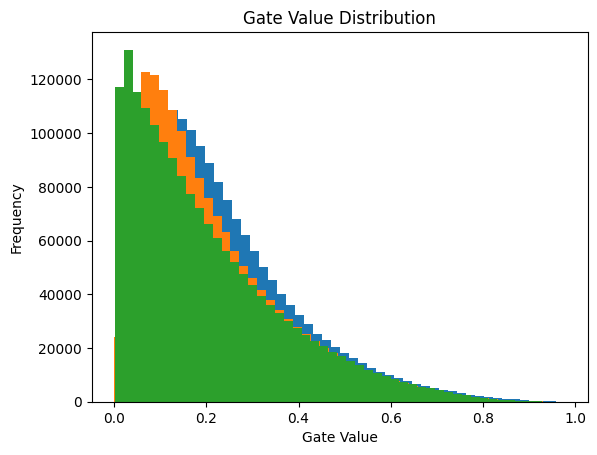

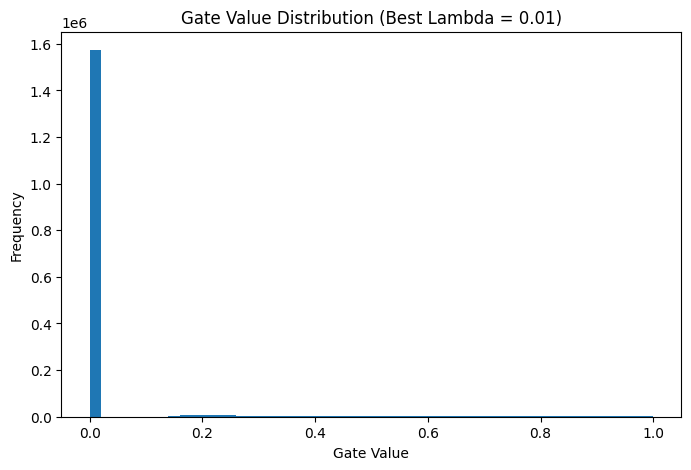

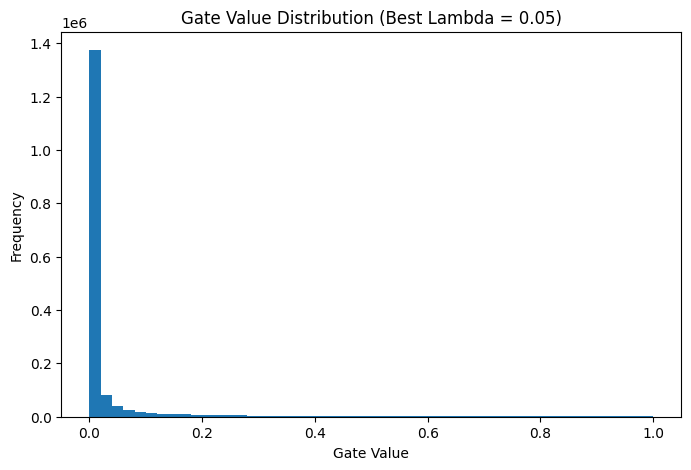

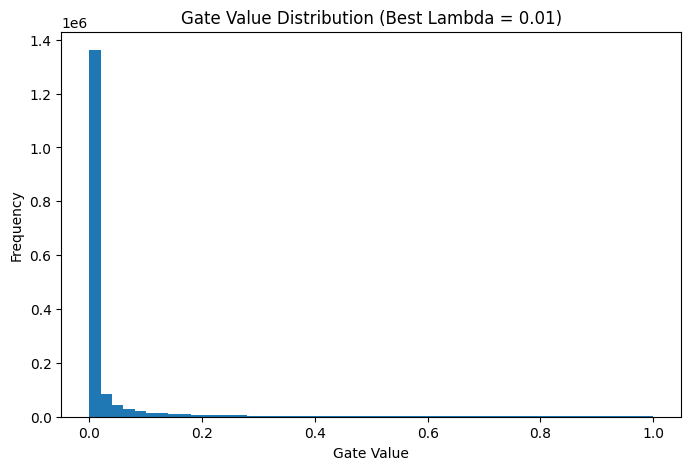

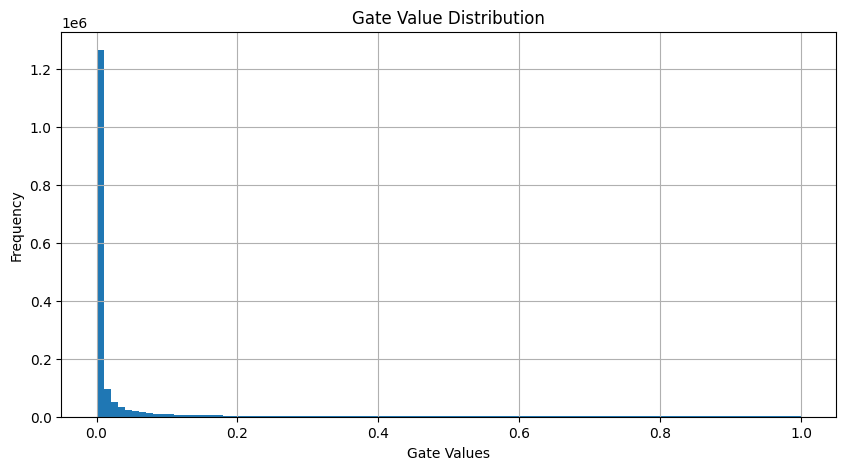

In [39]:
%matplotlib inline
# =========================
# Improved Visualization
# =========================
plt.figure(figsize=(10,5))

plt.hist(best_gates, bins=100)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

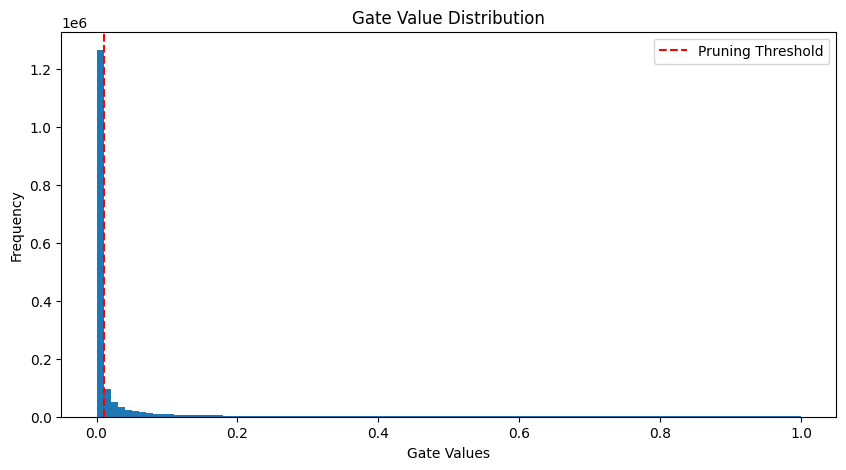

In [40]:
plt.figure(figsize=(10,5))
plt.hist(best_gates, bins=100)
plt.axvline(x=0.01, color='r', linestyle='--', label='Pruning Threshold')

plt.title("Gate Value Distribution")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.legend()
plt.show()